# Case1 moderate anisotropy with partial observation

## Pacakages and Functions

In [28]:
import torch
import numpy as np
from inc_ensf import EnSF
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import math
from scipy.linalg import qr
from matplotlib.collections import LineCollection
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

xlim_upper, xli_lower = 300, -300
use_this = 'cuda:0'

In [ ]:
class EnVar3D:
    def __init__(
        self,
        H,
        y_obs,
        B,
        R,
        Xb,
        obs_idx,
        learning_rate=1e-2,
        max_iterations=100,
        convergence_threshold=1e-5,
        device=use_this
    ):
        self.device = device
        self.obs_idx = obs_idx
        self.H = H  # Observation operator (callable)
        self.y_obs = y_obs.to(device)
        self.B_inv = torch.linalg.inv(B).to(device)
        self.B = B.to(device)
        self.L = torch.linalg.cholesky(self.B)  # B = L L^T
        self.R_inv = torch.linalg.inv(R).to(device)
        self.x_prior = Xb.to(device)  # Background ensemble (N, state_dim)
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.convergence_threshold = convergence_threshold
        self.ensemble_size, self.state_dim = self.x_prior.shape
        self.x_inc_init = torch.zeros_like(self.x_prior).to(device)

    def run(self):
        sparse_index = torch.zeros(self.x_prior.size(dim = 1),dtype=torch.bool,device=self.device)
        sparse_index[self.obs_idx] = True
        x_inc = torch.zeros_like(self.x_prior, requires_grad=True).to(self.device)
        prev_cost = float('inf')
        idx_nan = False
        output = torch.zeros(self.max_iterations+1,self.ensemble_size,self.state_dim).to(self.device)
        cost_output = torch.zeros(self.max_iterations+1).to(self.device)
        output[0] = (self.x_prior + x_inc)
        for iteration in range(self.max_iterations):
            if x_inc.grad is not None:
                x_inc.grad.zero_()
            # Apply observation operator
            Hx_inc = self.H(x_inc - self.x_inc_init)
            obs_inc = (self.y_obs - self.H(self.x_prior))
            # Innovation
            innovation = Hx_inc - obs_inc
            R_inv = self.R_inv.clone()
            R_inv[:,~sparse_index] = 0
            
            cost_obs = 0.5 * torch.einsum("ij,jk,ik->i", innovation.float(), R_inv.float(), innovation.float()) 
            y = torch.cholesky_solve(x_inc.unsqueeze(-1), self.L).squeeze(-1)  # shape (N, state_dim)
            cost_bkg = 0.5 * torch.einsum("ij,ij->i", x_inc, y)
            cost = cost_obs + cost_bkg
            #print(self.B_inv)

            grad_x_inc = torch.autograd.grad(outputs=cost,
                                 inputs=x_inc,
                                 grad_outputs=torch.ones_like(cost), 
                                 create_graph=True)[0]


            with torch.no_grad():
                x_inc -= self.learning_rate * grad_x_inc
            cost_value = cost.mean().item()
            cost_output[iteration] = cost_value
            output[iteration+1] = (self.x_prior + x_inc)
            if (iteration < 10) or(iteration%10000 == 0):
                print(f"Iteration {iteration+1}: Cost = {cost_value:.6f}")

            
            if cost_value>10000000000: 
                print("Cost is NaN")
                idx_nan = True
                break

            if abs(prev_cost - cost_value) < self.convergence_threshold:
                print("Convergence reached.")
                break

            prev_cost = cost_value

        # Final analysis state 
        x_analysis = self.x_prior + x_inc
        return x_analysis , idx_nan,  output[:iteration+2] #,cost_output[:iteration+1]
    

def cov_generate(n,lambda_1,lambda_rest):
    # n: dimension
    # 1. Direction of the line (e.g., all ones)
    v = np.ones(n)
    v /= np.linalg.norm(v)  # Normalize

    # 2. Create an orthonormal basis using QR decomposition
    # Stack v with random orthogonal vectors
    random_matrix = np.random.randn(n, n)
    random_matrix[:, 0] = v  # Set first column as v

    # QR gives orthonormal basis
    Q, _ = qr(random_matrix)  # Q is orthonormal, v is Q[:, 0]

    Lambda = np.diag([lambda_1] + [lambda_rest] * (n - 1))

    # 4. Build covariance matrix
    Sigma = Q @ Lambda @ Q.T  # Q * diag * Q^T
    Sigma += 1e-3 * np.eye(Sigma.shape[0])  # add jitter
    return Sigma


## generate sample

In [10]:
#test question
N_dim=10
ensemble_size = 10000
main_var = 10
other_var = 1.00
# generate samples
torch.manual_seed(100)
np.random.seed(8)
mean = torch.zeros(N_dim, device= use_this, dtype=torch.float32)
covariance_matrix = torch.tensor(cov_generate(N_dim,main_var,other_var), device= use_this, dtype=torch.float32)
mvn = torch.distributions.MultivariateNormal(mean, covariance_matrix)
test_sample = mvn.sample(sample_shape=(ensemble_size,))
test_sample[0] = 0
# print(test_sample.mean(dim=0),"\n",test_sample.T.cov(), "\n",torch.linalg.cond(covariance_matrix))


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


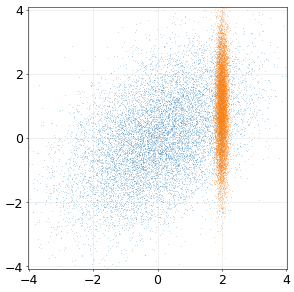

In [38]:
def to_numpy(a):
    return a.detach().cpu().numpy() if hasattr(a, "detach") else np.asarray(a)

test_all = to_numpy(test_sample)
# # =========================
# # 1) Build "result" samples by conditioning on x[d0] = x0_obs
# # =========================


Sigma = covariance_matrix.detach().cpu().numpy() if hasattr(covariance_matrix, "detach") else np.asarray(covariance_matrix)
n = Sigma.shape[0]

d0 = 0          # observed dimension
y  = 2      # observation value. 
sigma_obs = 0.1   

R = sigma_obs**2  
K = Sigma[:, d0] / (Sigma[d0, d0] + R)
mu_a = K * y
# Posterior covariance (n,n)
Sigma_a = Sigma - np.outer(Sigma[:, d0], Sigma[d0, :]) / (Sigma[d0, d0] + R)
# Sample posterior
rng = np.random.default_rng(123)
result_all = rng.multivariate_normal(mu_a, Sigma_a, size=ensemble_size)

for i in range(1):
    for j in range(i+1,2):
        dim_plot = [i,j]
        # choose 2D projection dims
        d0, d1 = dim_plot[0], dim_plot[1]
        # 2D arrays for plotting
        test   = test_all[:, [d0, d1]]
        result = result_all[:, [d0, d1]]

        # means/covs in 2D
        mean_test   = test.mean(axis=0)
        cov_test    = np.cov(test.T)

        mean_result = result.mean(axis=0)
        cov_result  = np.cov(result.T)
        ref_loc = mean_result.copy()
        # =========================
        # 2) Ellipse helper (yours)
        # =========================
        def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals, eigvecs = eigvals[order], eigvecs[:, order]
            angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
            width, height = 2 * n_std * np.sqrt(np.maximum(eigvals, 0))
            ellipse = Ellipse(xy=pos, width=width, height=height, angle=angle, **kwargs)
            ax.add_patch(ellipse)
            return ellipse

        # =========================
        # 3) Plot: prior vs post + path + ellipses
        # =========================
        fig, ax = plt.subplots(figsize=(6, 6),dpi=50)

        # scatter (keep s tiny; enlarge legend markers separately)
        ax.scatter(test[:, 0], test[:, 1], alpha=0.5, label="prior", s=0.09)
        ax.scatter(result[:, 0], result[:, 1], alpha=0.5, label="post (cond)", s=0.09)
        
        # covariance ellipses
        plot_cov_ellipse(cov_test,   mean_test,   ax, edgecolor="tab:blue", facecolor="none", linewidth=0.1,
                        label="Cov ellipse prior")
        plot_cov_ellipse(cov_result, mean_result, ax, edgecolor="tab:orange",  facecolor="none", linewidth=0.1,
                        label="Cov ellipse post")
        
        ax.axis("equal")
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.xaxis.set_major_locator(MultipleLocator(2))   # x-axis tick every 5
        ax.yaxis.set_major_locator(MultipleLocator(2))   # y-axis tick every 5
        ax.xaxis.label.set_size(20)
        ax.yaxis.label.set_size(20)
        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.grid(alpha = 0.3)
        plt.tight_layout()
        sigma_str = f"{sigma_obs:g}".replace(".", "p")
        plt.show()
        plt.close()

## EnSF

### ensemble-mean paths

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


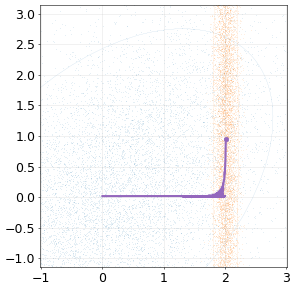

In [32]:
testensf = EnSF(n_dim = N_dim, ensemble_size = ensemble_size ,eps_alpha=0.01, eps_beta= 0.00, device= use_this ,obs_sigma = 0.1, euler_steps = 1)
ensf_iteration = 100 # 1000 or 10000
result1,score,cond_save = testensf.RSDE_incremental(obs=2, x0=0, x_prior=test_sample.clone(), time_steps=ensf_iteration, ens_cov=covariance_matrix/0.3, sparse_idx=[0],cov_scale = 0.3, tau_scale = 1) 

#path mean
x = (result1).cpu().detach().numpy()
for i in range(1):
    for j in range(i+1,2):
        dim_plot = [i,j]
        rotated_test_sample = test_sample[:,dim_plot] 
        d0, d1 = dim_plot[0], dim_plot[1]
        ref_loc = result_all[:, [d0, d1]].mean(axis=0)
        test = rotated_test_sample.cpu().numpy()  #rotated_test_sample
        result = ((result1[:,dim_plot,-1])) .cpu().numpy() #+test_sample[:,dim_plot]
        # Define the 2D covariance matrix
        cov_test = np.cov(test.T)
        cov_result = np.cov(result.T)

        # Mean of the distribution (center of the ellipse)
        mean_test = test.mean(axis = 0)
        mean_result = result.mean(axis = 0)
        # Generate samples from the multivariate normal distribution

        # Plot the samples
        fig, ax = plt.subplots(figsize=(6, 6),dpi=50)
        ax.scatter(test[:, 0], test[:, 1], alpha=0.5, label="prior", s=0.02)
        ax.scatter(result[:, 0], result[:, 1], alpha=0.5, label="post", s=0.02)
        ensf_path = x[:,dim_plot,:]
        plt.plot(ensf_path[:,0].mean(axis=0),ensf_path[:,1].mean(axis=0),linewidth=3,color = "tab:purple", label='EnSF')
        # Function to draw the covariance ellipse
        def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals, eigvecs = eigvals[order], eigvecs[:, order]
            angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
            width, height = 2 * n_std * np.sqrt(eigvals)
            ellipse = Ellipse(xy=pos, width=width, height=height, angle=angle, **kwargs)
            ax.add_patch(ellipse)
        handles, labels = ax.get_legend_handles_labels()
        # Draw the ellipse
        plot_cov_ellipse(cov_test,mean_test, ax, edgecolor='tab:blue', facecolor='none', linewidth=0.1, label='Covariance Ellipse Prior')
        plot_cov_ellipse(cov_result,mean_result, ax, edgecolor='tab:orange', facecolor='none', linewidth=0.1, label='Covariance Ellipse post')
        ax.scatter(mean_result[0], mean_result[1], alpha=1, color ="tab:purple" ,label="reference", s=40)
        # Add helper lines and labels
        ax.axis('equal')
        ax.set_xlim(-1, 3)
        ax.set_ylim(-1, 3)
        ax.xaxis.label.set_size(20)
        ax.yaxis.label.set_size(20)
        ax.tick_params(axis='both', which='major', labelsize=18)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close()


### conditioning evolution

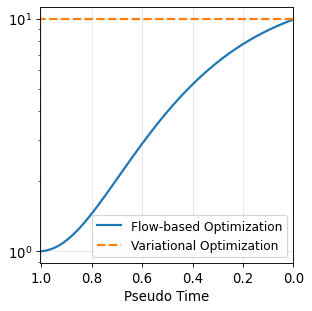

In [37]:
result1,score,cond_save = testensf.RSDE_incremental(obs=2, x0=0, x_prior=test_sample.clone(), time_steps=100, ens_cov=covariance_matrix/0.3, sparse_idx=[0],cov_scale = 0.3, tau_scale = 1) 
fig, ax = plt.subplots(figsize=(4, 4), dpi=80)
y1 = cond_save.cpu().numpy()
x = np.linspace(0, 1, len(y1))  # normalized x-axis [0, 1]
y2 = torch.linalg.cond(covariance_matrix).cpu().numpy()
ax.plot(1-x, y1, linewidth=2, label="Flow-based Optimization")
ax.plot(x, y2 * np.ones_like(y1), linewidth=2, linestyle="--", label="Variational Optimization")
ax.set_xlim(1.005, 0)
ax.set_xlabel("Pseudo Time", fontsize=12)
ax.set_yscale("log")
ax.legend(fontsize=11, loc = "lower right")
ax.grid(alpha=0.3)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

## 3DEnVar

### ensemble-mean paths

Iteration 1: Cost = 29.516335
Iteration 2: Cost = 2.683330
Iteration 3: Cost = 2.422936
Iteration 4: Cost = 2.386725
Iteration 5: Cost = 2.353629
Iteration 6: Cost = 2.321749
Iteration 7: Cost = 2.291027
Iteration 8: Cost = 2.261419
Iteration 9: Cost = 2.232885
Iteration 10: Cost = 2.205387


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Convergence reached.


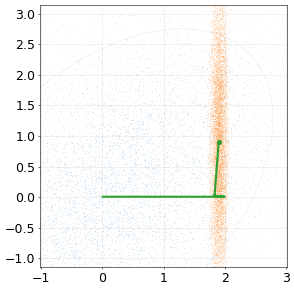

In [39]:
#sparse obs
H = lambda x: x
obs = torch.tensor((2))
# Create EnVar instance
envar = EnVar3D(H=H, y_obs=obs, B = covariance_matrix, R=torch.eye(N_dim)*0.1, Xb= test_sample.clone(),obs_idx=[0], learning_rate=0.1, max_iterations=1000, convergence_threshold=1e-6)
# Run assimilation
x_analysis,nan_idx, x_path = envar.run()

#path mean
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
x = (x_path).cpu().detach().numpy()
for i in range(1):
    for j in range(i+1,2):
        dim_plot = [i,j]
        rotated_test_sample = test_sample[:,dim_plot] 
        d0, d1 = dim_plot[0], dim_plot[1]
        ref_loc = result_all[:, [d0, d1]].mean(axis=0)
        test = rotated_test_sample.cpu().numpy()  #rotated_test_sample
        result = ((x_analysis[:,dim_plot].detach().cpu().numpy()))
        # Define the 2D covariance matrix
        cov_test = np.cov(test.T)
        cov_result = np.cov(result.T)
        mean_test = test.mean(axis = 0)
        mean_result = result.mean(axis = 0)
        # Plot the samples
        fig, ax = plt.subplots(figsize=(6, 6),dpi=50)
        ax.scatter(test[:, 0], test[:, 1], alpha=0.5, label="prior", s=0.02)
        ax.scatter(result[:, 0], result[:, 1], alpha=0.5, label="post", s=0.02)

        # Function to draw the covariance ellipse
        def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals, eigvecs = eigvals[order], eigvecs[:, order]
            angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
            width, height = 2 * n_std * np.sqrt(eigvals)
            ellipse = Ellipse(xy=pos, width=width, height=height, angle=angle, **kwargs)
            ax.add_patch(ellipse)

        # Draw the ellipse
        plot_cov_ellipse(cov_test,mean_test, ax, edgecolor='tab:blue', facecolor='none', linewidth=0.1, label='Covariance Ellipse Prior')
        plot_cov_ellipse(cov_result,mean_result, ax, edgecolor='tab:orange', facecolor='none', linewidth=0.1, label='Covariance Ellipse post')
        ensf_path = x[:,:,dim_plot].mean(axis=1)
        plt.plot(ensf_path[:,0],ensf_path[:,1],linewidth=3, color='tab:green', label='3DEnVar')
        ax.scatter(mean_result[0], mean_result[1], alpha=1, color ="tab:green" ,label="reference", s=40)
        ax.axis('equal')
        ax.set_xlim(-1, 3)
        ax.set_ylim(-1, 3)
        ax.xaxis.label.set_size(20)
        ax.yaxis.label.set_size(20)
        ax.tick_params(axis='both', which='major', labelsize=18)
        plt.grid(alpha = 0.3)
        plt.tight_layout()
        plt.show()
        plt.close()

